In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import requests
import pandas as pd
import numpy as np
import os
import time
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from scipy.stats import norm, skew

# Add your path at
``` OUTDIR = " " ```

In [ ]:
OUTDIR = "/content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output"
os.makedirs(OUTDIR, exist_ok=True)
print(f"Output will be written to {OUTDIR}")

Output will be written to /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output


# Indicators to fetch

In [ ]:
selected_ids = {
    "NY.GDP.MKTP.KD.ZG": "GDP growth (annual %)",
    "SP.POP.TOTL": "Population, total",
    "SE.PRM.ENRR": "School enrollment, primary (% gross)",
    "SI.POV.DDAY": "Poverty headcount ratio ($2.15 a day) (% of population)",
    "IT.NET.USER.ZS": "Individuals using the Internet (% of population)",
    "SL.UEM.TOTL.ZS": "Unemployment, total (% of labor force)"
}

# Get list of actual countries (Although didn't use it again because i notice sometimes it return error). Just something to note

In [ ]:
countries_url = "https://api.worldbank.org/v2/country?format=json&per_page=500"
countries_data = requests.get(countries_url).json()[1]
country_codes = [c["id"] for c in countries_data if c["region"]["id"] != "NA"]

# Fetch indicator data for countries only

In [ ]:
records = []
for ind_id, ind_name in selected_ids.items():
    codes_str = ";".join(country_codes)
    # url = f"https://api.worldbank.org/v2/country/{codes_str}/indicator/{ind_id}?format=json&per_page=20000"
    url = f"https://api.worldbank.org/v2/country/all/indicator/{ind_id}?format=json&per_page=20000"
    r = requests.get(url)
    # Check if the request was successful and the response is not empty
    if r.status_code != 200 or not r.text:
        print(f"Warning: Could not fetch data for indicator {ind_id}")
        continue

    try:
        data = r.json()
    except requests.exceptions.JSONDecodeError:
        print(f"Warning: Could not decode JSON for indicator {ind_id}")
        continue

    if len(data) < 2:
        continue

    for entry in data[1]:
        if entry["countryiso3code"] not in country_codes:
            continue
        if entry["value"] is None:
            continue
        records.append({
            "country": entry["country"]["value"],
            "iso3": entry["countryiso3code"],
            "year": int(entry["date"]),
            "indicator_id": ind_id,
            "indicator_name": ind_name,
            "value": entry["value"]
        })

# Convert and clean (2000 and above)

In [ ]:
df = pd.DataFrame(records)
# df[df['country'] == "United Kingdom"]
df = df[df["year"] >= 2000]

In [ ]:
df

,country,iso3,year,indicator_id,indicator_name,value
0,Afghanistan,AFG,2023,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),2.266944
1,Afghanistan,AFG,2022,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),-6.240172
2,Afghanistan,AFG,2021,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),-20.738839
3,Afghanistan,AFG,2020,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),-2.351101
4,Afghanistan,AFG,2019,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),3.911603
...,...,...,...,...,...,...
46995,Zimbabwe,ZWE,2004,SL.UEM.TOTL.ZS,"Unemployment, total (% of labor force)",4.390000
46996,Zimbabwe,ZWE,2003,SL.UEM.TOTL.ZS,"Unemployment, total (% of labor force)",4.735000
46997,Zimbabwe,ZWE,2002,SL.UEM.TOTL.ZS,"Unemployment, total (% of labor force)",5.007000
46998,Zimbabwe,ZWE,2001,SL.UEM.TOTL.ZS,"Unemployment, total (% of labor force)",5.318000


# Pivot for easy analysis

In [ ]:
df_pivot = df.pivot_table(
    index=["country", "year"],
    columns="indicator_name",
    values="value"
).reset_index()

In [ ]:
print(f"{len(df_pivot)} country year data points (no regions).")
df_pivot.head(10)

5425 country year data points (no regions).


indicator_name,country,year,GDP growth (annual %),Individuals using the Internet (% of population),"Population, total",Poverty headcount ratio ($2.15 a day) (% of population),"School enrollment, primary (% gross)","Unemployment, total (% of labor force)"
0,Afghanistan,2000,NaN,NaN,20130327.0,NaN,21.457850,7.935
1,Afghanistan,2001,-9.431974,0.004723,20284307.0,NaN,22.139650,7.953
2,Afghanistan,2002,28.600001,0.004561,21378117.0,NaN,73.401314,7.930
3,Afghanistan,2003,8.832278,0.087891,22733049.0,NaN,95.335747,7.880
4,Afghanistan,2004,1.414118,0.105809,23560654.0,NaN,105.475052,7.899
5,Afghanistan,2005,11.229715,1.224150,24404567.0,NaN,99.503906,7.885
6,Afghanistan,2006,5.357403,2.107120,25424094.0,NaN,102.284866,7.914
7,Afghanistan,2007,13.826320,1.900000,25909852.0,NaN,99.322899,7.817
8,Afghanistan,2008,3.924984,1.840000,26482622.0,NaN,104.445137,7.878
9,Afghanistan,2009,21.390528,3.550000,27466101.0,NaN,99.705421,7.754


In [ ]:
df.shape

(25912, 6)

In [ ]:
processed_csv = os.path.join(OUTDIR, "processed_data.csv")
df_pivot.to_csv(processed_csv, index=False)
print(f"Processed data saved to {processed_csv}")

Processed data saved to /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/processed_data.csv


# Data coverage (number of non-null rows) per indicator

In [ ]:
coverage = df_pivot[selected_ids.values()].notna().sum().sort_values(ascending=False)
print("\nData coverage (number of non-null rows) per indicator:")
print(coverage)


Data coverage (number of non-null rows) per indicator:
indicator_name
Population, total                                          5425
GDP growth (annual %)                                      5141
Individuals using the Internet (% of population)           4754
Unemployment, total (% of labor force)                     4666
School enrollment, primary (% gross)                       4092
Poverty headcount ratio ($2.15 a day) (% of population)    1834
dtype: int64


In [ ]:
df.head()

,country,iso3,year,indicator_id,indicator_name,value
0,Afghanistan,AFG,2023,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),2.266944
1,Afghanistan,AFG,2022,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),-6.240172
2,Afghanistan,AFG,2021,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),-20.738839
3,Afghanistan,AFG,2020,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),-2.351101
4,Afghanistan,AFG,2019,NY.GDP.MKTP.KD.ZG,GDP growth (annual %),3.911603


In [ ]:
df.isnull().sum()

,0
country,0
iso3,0
year,0
indicator_id,0
indicator_name,0
value,0


# Summary of the Stat, stating the count, mean, std etc of all indicators

In [ ]:
num_stats = df_pivot[selected_ids.values()].describe().transpose()
display(num_stats)

,count,mean,std,min,25%,50%,75%,max
indicator_name,,,,,,,,
GDP growth (annual %),5141.0,3.359559e+00,5.976554e+00,-54.336106,1.213024,3.508283e+00,5.821121e+00,9.113704e+01
"Population, total",5425.0,3.294140e+07,1.305947e+08,9544.000000,728147.000000,5.773493e+06,2.106840e+07,1.450936e+09
"School enrollment, primary (% gross)",4092.0,1.017522e+02,1.382278e+01,20.915550,97.001495,1.015486e+02,1.079306e+02,1.839894e+02
Poverty headcount ratio ($2.15 a day) (% of population),1834.0,9.410087e+00,1.712624e+01,0.000000,0.200000,1.400000e+00,9.400000e+00,9.490000e+01
Individuals using the Internet (% of population),4754.0,3.930379e+01,3.205848e+01,0.000000,7.613218,3.373625e+01,6.900000e+01,1.000000e+02
"Unemployment, total (% of labor force)",4666.0,8.019864e+00,6.021132e+00,0.100000,3.711000,6.109500e+00,1.084975e+01,3.732000e+01


In [ ]:
num_stats.to_csv(os.path.join(OUTDIR, "wb_summary_stats.csv"))
print("Summary stats saved.")

Summary stats saved.


In [ ]:
n_countries = df_pivot["country"].nunique()
n_years = df_pivot["year"].nunique()
print(f"Data covers {n_countries} countries and {n_years} years.")

Data covers 217 countries and 25 years.


In [ ]:
rows_per_country = df_pivot.groupby("country").size().sort_values(ascending=False)
print("\nRows per country:")
rows_per_country.head(10)


Rows per country:


,0
country,
Afghanistan,25
Albania,25
Algeria,25
American Samoa,25
Andorra,25
Angola,25
Antigua and Barbuda,25
Argentina,25
Armenia,25


# Ensure all columns are numeric

In [ ]:
indicators = selected_ids.values()
for col in indicators:
    df_pivot[col] = pd.to_numeric(df_pivot[col], errors='coerce')

def pair_cor(df, inds):
    pearson = pd.DataFrame(index=inds, columns=inds, dtype=float)
    spearman = pd.DataFrame(index=inds, columns=inds, dtype=float)

    for i in inds:
        for j in inds:
            sub = df[[i, j]].dropna()

            if len(sub) >= 5:
                # Compute correlation safely
                try:
                    pearson.loc[i, j] = stats.pearsonr(sub[i], sub[j])[0]
                    spearman.loc[i, j] = stats.spearmanr(sub[i], sub[j])[0]
                except Exception as e:
                    pearson.loc[i, j] = np.nan
                    spearman.loc[i, j] = np.nan
            else:
                pearson.loc[i, j] = np.nan
                spearman.loc[i, j] = np.nan

    return pearson, spearman

# Fill missing Values with the Mean

In [ ]:
print("Missing values in df_pivot:")
print(df_pivot.isnull().sum())

Missing values in df_pivot:
indicator_name
country                                                       0
year                                                          0
GDP growth (annual %)                                       284
Individuals using the Internet (% of population)            671
Population, total                                             0
Poverty headcount ratio ($2.15 a day) (% of population)    3591
School enrollment, primary (% gross)                       1333
Unemployment, total (% of labor force)                      759
dtype: int64


In [ ]:
numeric_cols = df_pivot.select_dtypes(include=np.number).columns
df_pivot[numeric_cols] = df_pivot[numeric_cols].fillna(df_pivot[numeric_cols].mean())

In [ ]:
print("Missing values in df_pivot:")
print(df_pivot.isnull().sum())

Missing values in df_pivot:
indicator_name
country                                                    0
year                                                       0
GDP growth (annual %)                                      0
Individuals using the Internet (% of population)           0
Population, total                                          0
Poverty headcount ratio ($2.15 a day) (% of population)    0
School enrollment, primary (% gross)                       0
Unemployment, total (% of labor force)                     0
dtype: int64


In [ ]:
pearson_corr, spearman_corr = pair_cor(df_pivot, indicators)

# Fill NaNs with the mean of the existing (non-NaN) correlations
pearson_mean = pearson_corr.stack().mean()   # stack() drops NaNs automatically
spearman_mean = spearman_corr.stack().mean()

pearson_corr = pearson_corr.fillna(pearson_mean)
spearman_corr = spearman_corr.fillna(spearman_mean)

In [ ]:
pearson_corr.round(3)

,GDP growth (annual %),"Population, total","School enrollment, primary (% gross)",Poverty headcount ratio ($2.15 a day) (% of population),Individuals using the Internet (% of population),"Unemployment, total (% of labor force)"
GDP growth (annual %),-0.036,0.067,0.015,0.075,-0.159,-0.088
"Population, total",0.067,-0.036,0.002,0.026,-0.029,-0.080
"School enrollment, primary (% gross)",0.015,0.002,-0.036,0.010,-0.012,0.076
Poverty headcount ratio ($2.15 a day) (% of population),0.075,0.026,0.010,-0.036,-0.359,-0.052
Individuals using the Internet (% of population),-0.159,-0.029,-0.012,-0.359,-0.036,-0.027
"Unemployment, total (% of labor force)",-0.088,-0.080,0.076,-0.052,-0.027,-0.036


# HeatMap; analyzing Pearson correlation matrix (indicators)

Saved heatmap to: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/pearson_heatmap.png


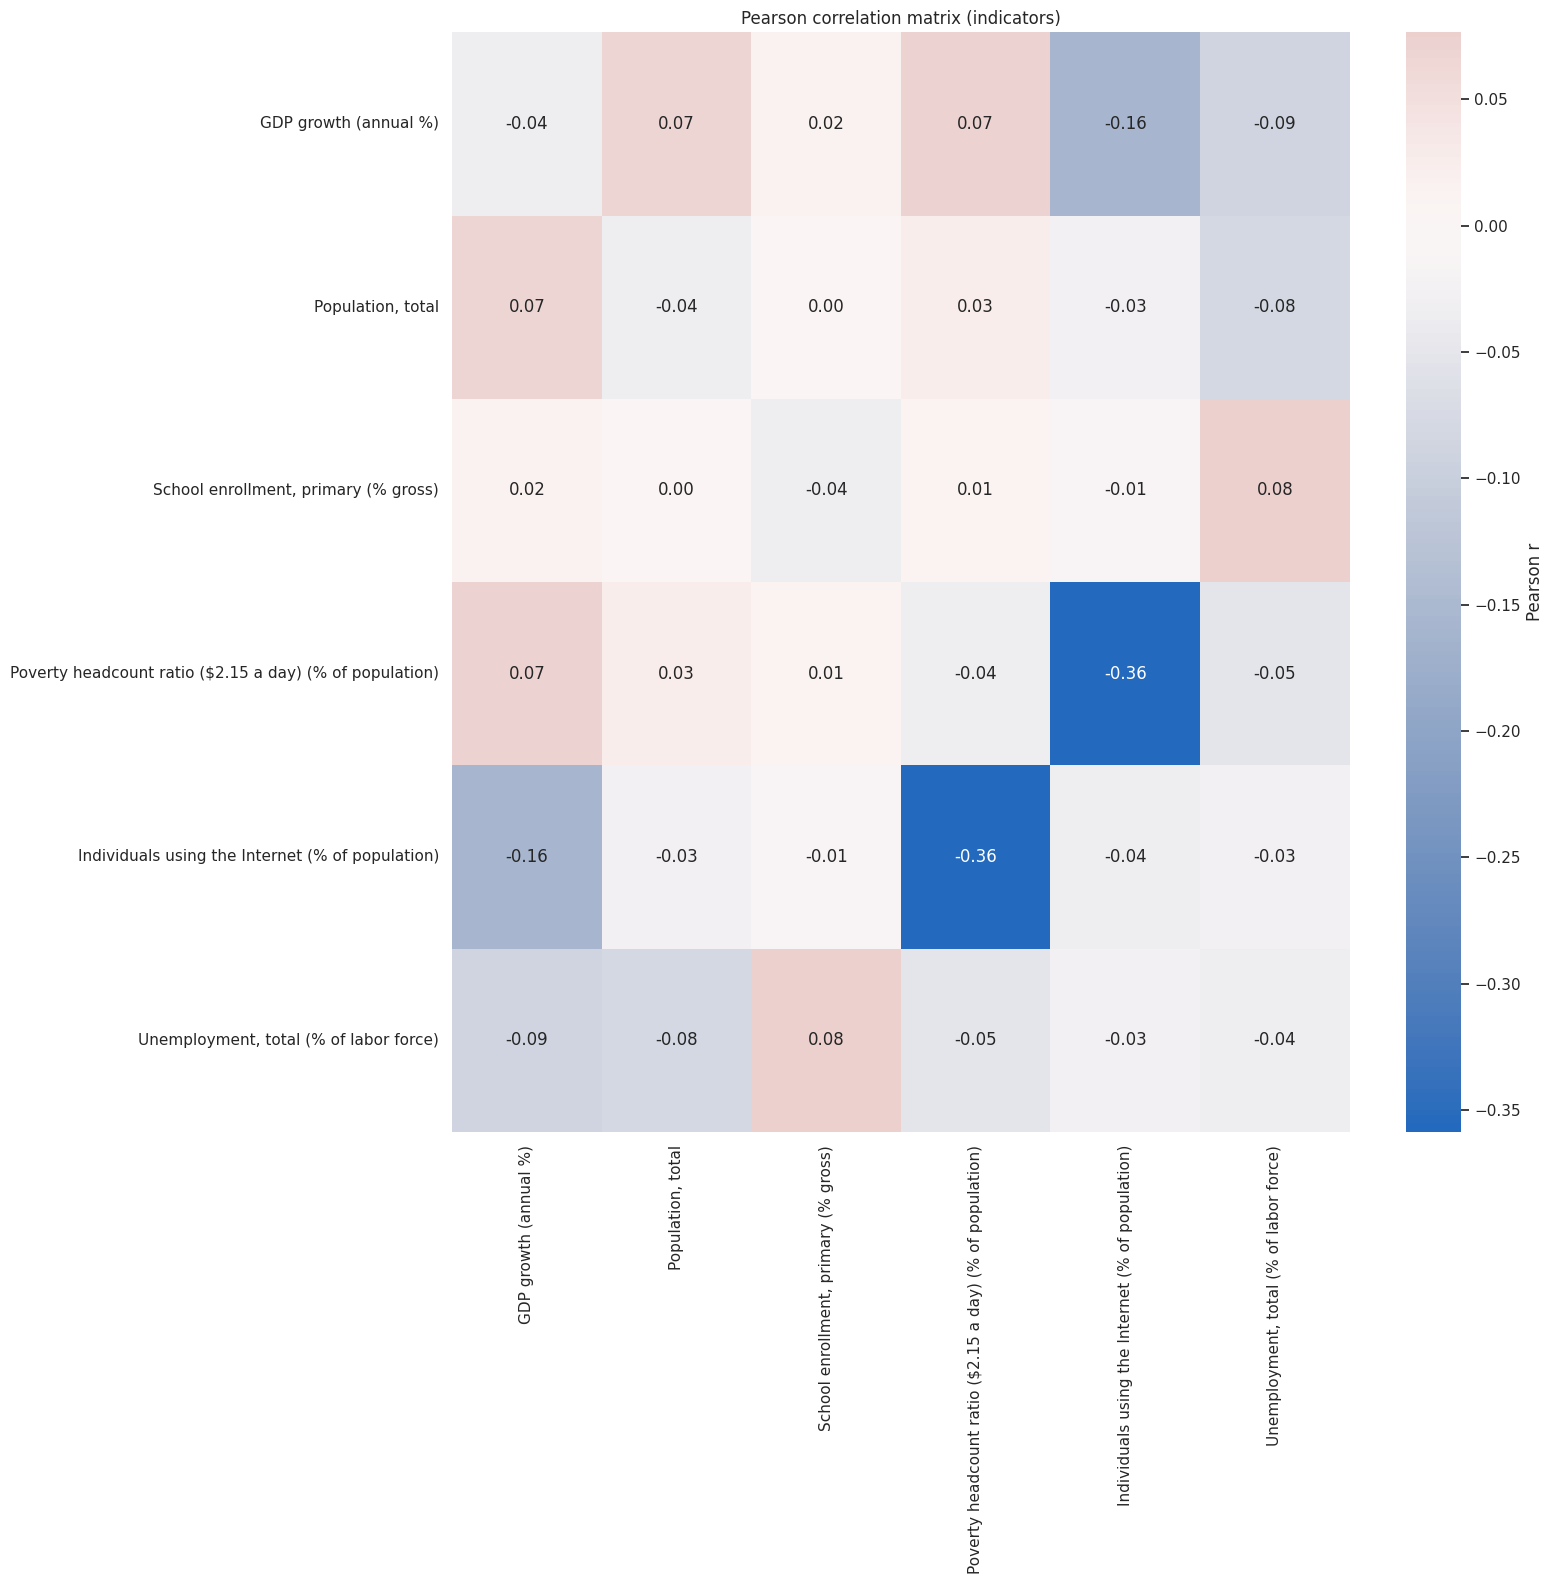

In [ ]:
plt.rcParams.update({'figure.max_open_warning': 0})
sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize=(16,16))

sns.heatmap(pearson_corr.astype(float), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Pearson correlation matrix (indicators)")
plt.tight_layout()
heatmap_path = os.path.join(OUTDIR, "pearson_heatmap.png")
fig.savefig(heatmap_path, dpi=200)
print("Saved heatmap to:", heatmap_path)
plt.show()


# Scatter plot with regression line and printed regression stats

Number of global datapoints used for scatter/regression: 5425
Linear fit: slope=0.0074, intercept=2.607, r=0.015, p=0.261, n=5425
Saved scatter plot to: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/school_vs_gdp_scatter.png


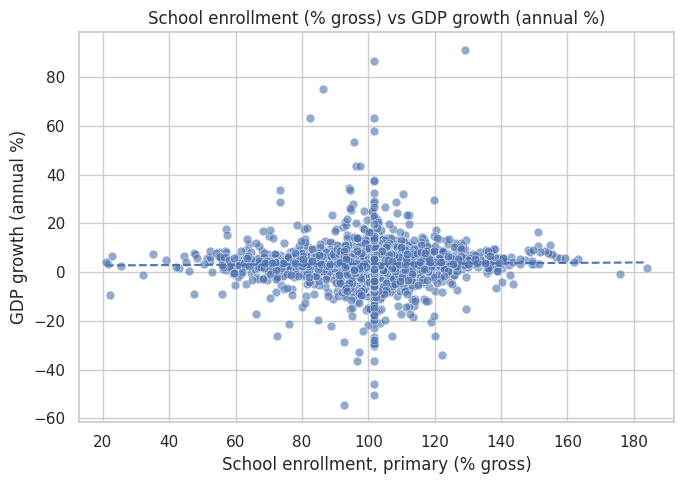

In [ ]:
x_col = "School enrollment, primary (% gross)"
y_col = "GDP growth (annual %)"

sub = df_pivot[[x_col, y_col]].dropna()
print("Number of global datapoints used for scatter/regression:", len(sub))

plt.figure(figsize=(7,5))
sns.scatterplot(data=sub, x=x_col, y=y_col, alpha=0.6, s=40)
# linear fit using scipy
if len(sub) >= 2:
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub[x_col], sub[y_col])
    xs = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
    plt.plot(xs, slope*xs + intercept, linestyle='--', linewidth=1.5)
    print(f"Linear fit: slope={slope:.4f}, intercept={intercept:.3f}, r={r_value:.3f}, p={p_value:.3g}, n={len(sub)}")
else:
    print("Not enough points for regression.")
plt.title("School enrollment (% gross) vs GDP growth (annual %)")
plt.tight_layout()
scatter_path = os.path.join(OUTDIR, "school_vs_gdp_scatter.png")
plt.savefig(scatter_path, dpi=200)
print("Saved scatter plot to:", scatter_path)
plt.show()


# Trend plots for GDP vs Unemployment for top countries by completeness

In [ ]:
both_cols = ["Unemployment, total (% of labor force)", "GDP growth (annual %)"]
complete_counts = df_pivot.dropna(subset=both_cols).groupby("country").size().sort_values(ascending=False)
top_countries = complete_counts.head(6).index.tolist()
print("Top countries selected for trend plots (most-complete data for GDP & unemployment):")
print(top_countries)

Top countries selected for trend plots (most-complete data for GDP & unemployment):
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola']


Plotting Afghanistan: rows=25 years range 2000–2024


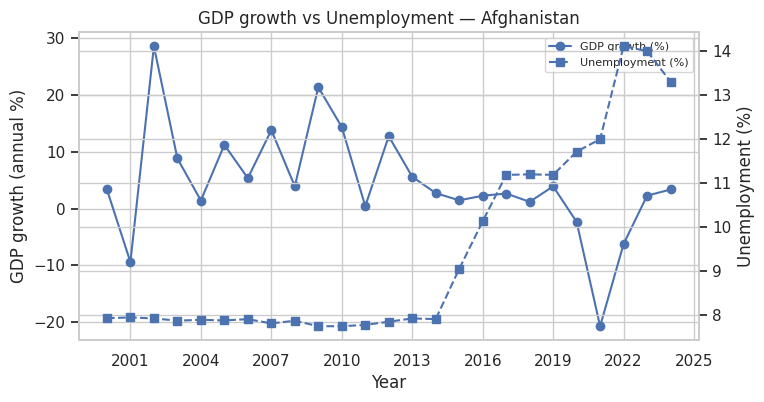

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/trend_gdp_unemployment_Afghanistan.png
Plotting Albania: rows=25 years range 2000–2024


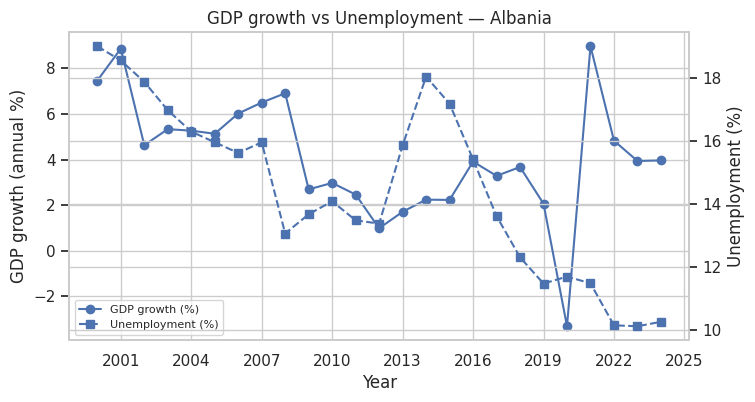

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/trend_gdp_unemployment_Albania.png
Plotting Algeria: rows=25 years range 2000–2024


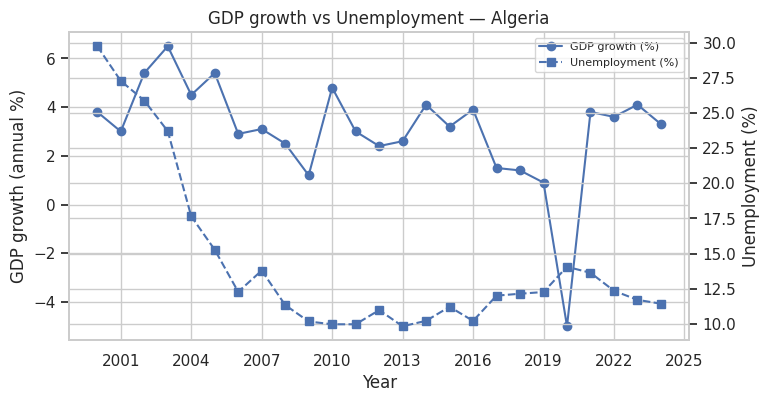

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/trend_gdp_unemployment_Algeria.png
Plotting American Samoa: rows=25 years range 2000–2024


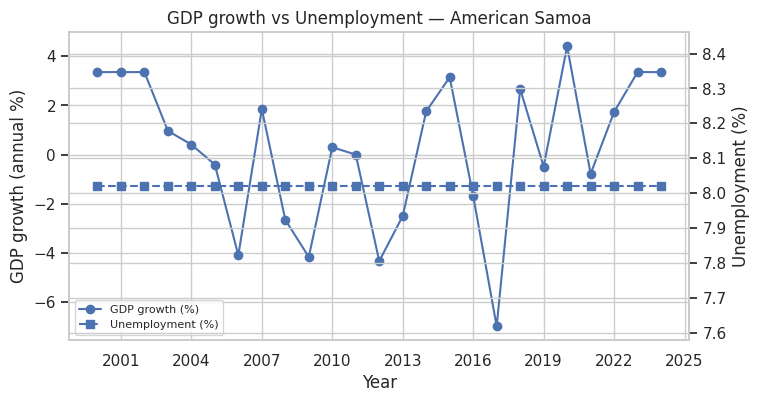

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/trend_gdp_unemployment_American_Samoa.png
Plotting Andorra: rows=25 years range 2000–2024


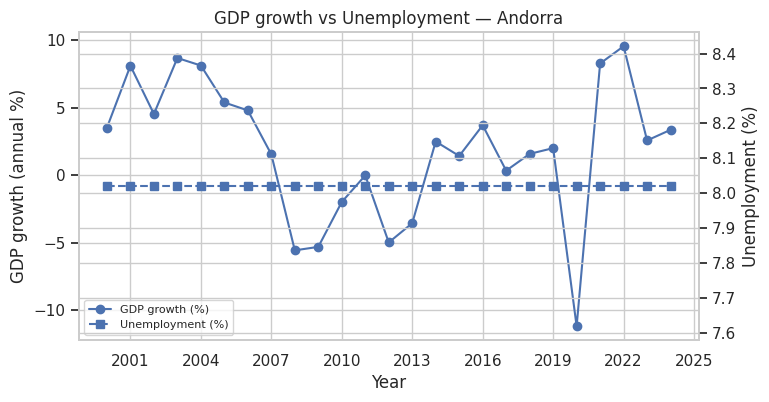

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/trend_gdp_unemployment_Andorra.png
Plotting Angola: rows=25 years range 2000–2024


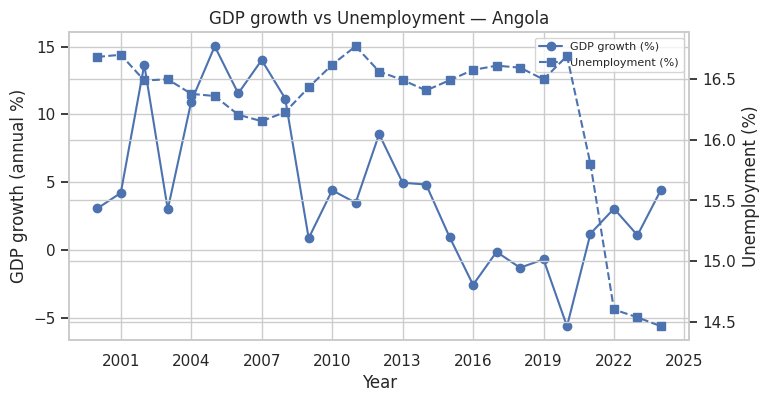

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/trend_gdp_unemployment_Angola.png


In [ ]:
for country in top_countries:
    cdf = df_pivot[df_pivot["country"] == country].sort_values("year")
    if cdf.empty:
        print("Skipping", country, "— no data")
        continue
    print(f"Plotting {country}: rows={len(cdf)} years range {cdf['year'].min()}–{cdf['year'].max()}")
    fig, ax1 = plt.subplots(figsize=(8,4))
    ax1.plot(cdf["year"], cdf["GDP growth (annual %)"], marker='o', label='GDP growth (%)')
    ax1.set_ylabel("GDP growth (annual %)")
    ax1.set_xlabel("Year")
    ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2 = ax1.twinx()
    ax2.plot(cdf["year"], cdf["Unemployment, total (% of labor force)"], marker='s', linestyle='--', label='Unemployment (%)')
    ax2.set_ylabel("Unemployment (%)")
    plt.title(f"GDP growth vs Unemployment — {country}")
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='best', fontsize=8)
    fname = os.path.join(OUTDIR, f"trend_gdp_unemployment_{country.replace(' ', '_')}.png")
    fig.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(" Saved:", fname)


# Compute population growth % (YoY) per country and plot against GDP growth

In [ ]:
pop_col = "Population, total"
gdp_col = "GDP growth (annual %)"

print("Computing YoY population growth (%) per country (using population total).")
pop_growth_records = []
for country, group in df_pivot.groupby("country"):
    grp = group.sort_values("year").copy()
    if pop_col in grp.columns:
        grp["pop_growth_pct"] = grp[pop_col].pct_change() * 100
        pop_growth_records.append(grp[["country", "year", "pop_growth_pct", gdp_col]])
pop_growth_df = pd.concat(pop_growth_records, ignore_index=True)
# Pick sample countries with both pop_growth and gdp available
sample_countries = pop_growth_df.dropna(subset=["pop_growth_pct", gdp_col]).groupby("country").size().sort_values(ascending=False).head(6).index.tolist()
print("Sample countries for pop vs gdp plotting:", sample_countries)

Computing YoY population growth (%) per country (using population total).
Sample countries for pop vs gdp plotting: ['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola']


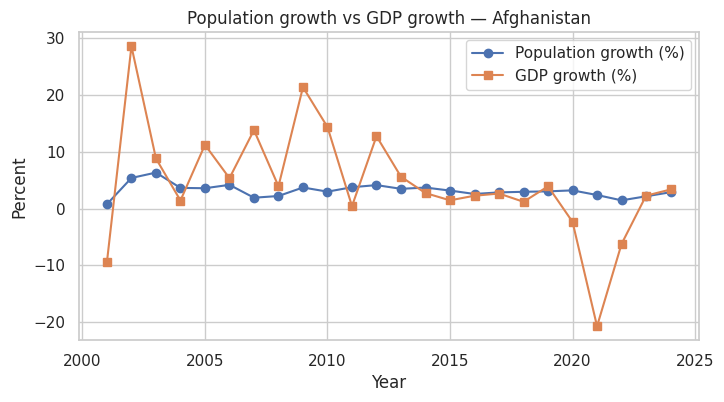

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/pop_vs_gdp_Afghanistan.png


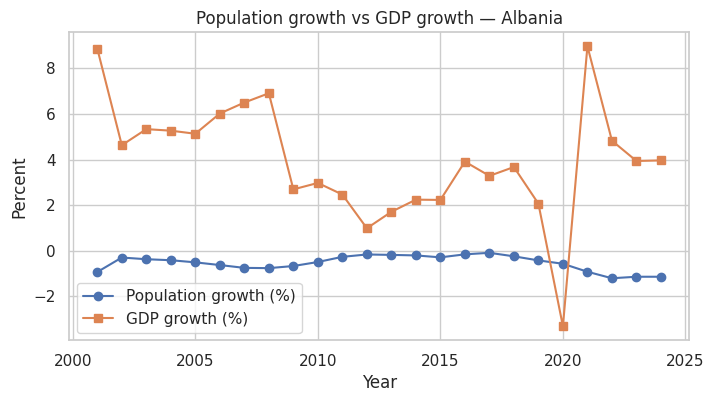

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/pop_vs_gdp_Albania.png


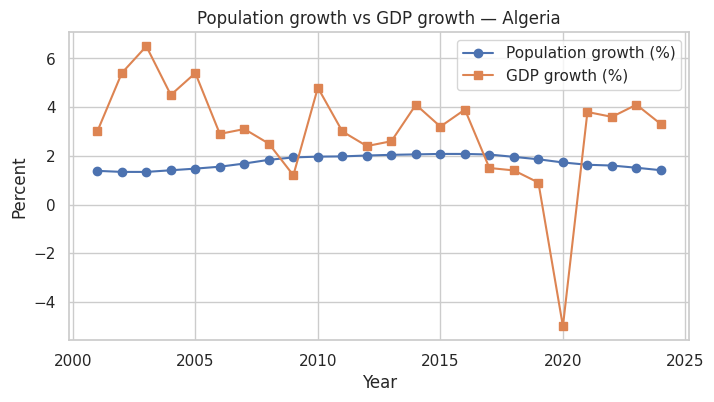

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/pop_vs_gdp_Algeria.png


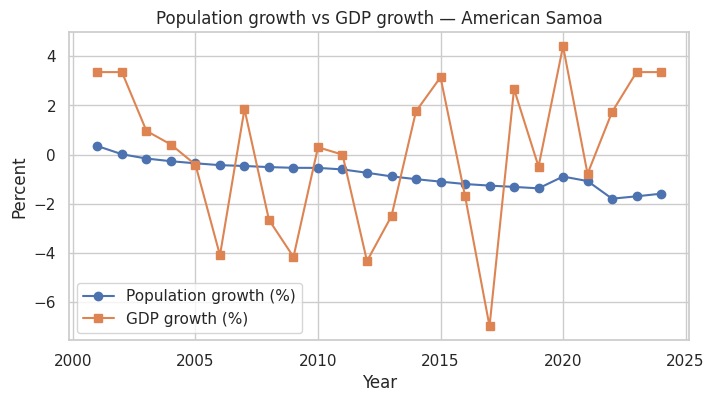

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/pop_vs_gdp_American_Samoa.png


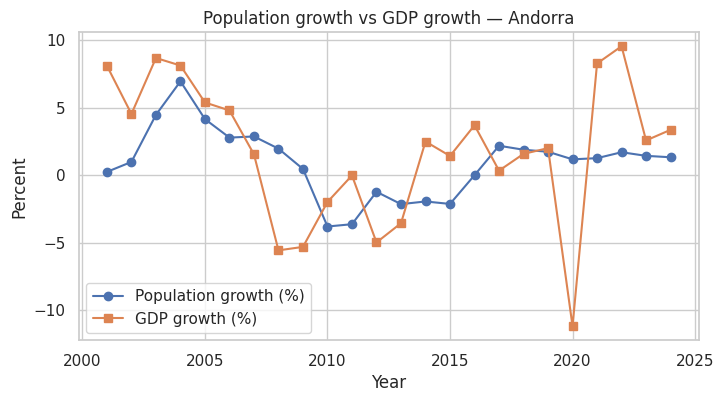

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/pop_vs_gdp_Andorra.png


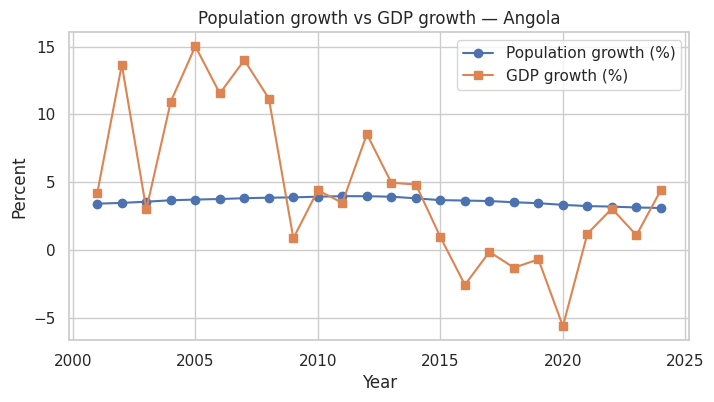

 Saved: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/pop_vs_gdp_Angola.png


In [ ]:
for c in sample_countries:
    cdf = pop_growth_df[pop_growth_df["country"] == c].sort_values("year").dropna(subset=["pop_growth_pct", gdp_col])
    if cdf.empty:
        continue
    plt.figure(figsize=(8,4))
    plt.plot(cdf["year"], cdf["pop_growth_pct"], marker='o', label='Population growth (%)')
    plt.plot(cdf["year"], cdf[gdp_col], marker='s', label='GDP growth (%)')
    plt.xlabel("Year")
    plt.ylabel("Percent")
    plt.title(f"Population growth vs GDP growth — {c}")
    plt.legend()
    fname = os.path.join(OUTDIR, f"pop_vs_gdp_{c.replace(' ', '_')}.png")
    plt.savefig(fname, dpi=200, bbox_inches='tight')
    plt.show()
    print(" Saved:", fname)


# Compute per-country Pearson r for school enrollment vs GDP and save

In [ ]:
x_col = "School enrollment, primary (% gross)"
y_col = "GDP growth (annual %)"
country_corrs = []
for country, grp in df_pivot.groupby("country"):
    sub = grp[[x_col, y_col]].dropna()
    if len(sub) >= 5:
        r, p = stats.pearsonr(sub[x_col], sub[y_col])
        country_corrs.append({"country": country, "pearson_r_school_gdp": r, "p_value": p, "n": len(sub)})

country_corrs_df = pd.DataFrame(country_corrs).sort_values("pearson_r_school_gdp", ascending=False)
print("Per-country correlations (top 10):")
display(country_corrs_df.head(10))
outpath = os.path.join(OUTDIR, "country_school_gdp_correlations.csv")
country_corrs_df.to_csv(outpath, index=False)
print("Saved per-country school vs GDP correlation CSV to:", outpath)


Per-country correlations (top 10):


,country,pearson_r_school_gdp,p_value,n
108,Lao PDR,0.846710,9.527449e-08,25
110,Lebanon,0.652191,4.111577e-04,25
194,Togo,0.650080,4.355548e-04,25
4,Andorra,0.605214,1.348724e-03,25
175,Solomon Islands,0.557385,3.796058e-03,25
29,Bulgaria,0.508115,9.507212e-03,25
41,China,0.489575,1.299274e-02,25
47,Cote d'Ivoire,0.473238,1.687987e-02,25
131,Mongolia,0.472302,1.712882e-02,25
81,Guinea,0.464400,1.935065e-02,25


Saved per-country school vs GDP correlation CSV to: /content/drive/MyDrive/Colab Notebooks/DSCI-511 Assignment and Quiz/Final Project/output/country_school_gdp_correlations.csv
